<a href="https://colab.research.google.com/github/VishalValvi-83/LP-V/blob/main/RNN(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[*********************100%***********************]  1 of 1 completed

Epoch 1/10



/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0521 - val_loss: 0.0020
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0011 - val_loss: 0.0016
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 9.9672e-04 - val_loss: 0.0018
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.2476e-04 - val_loss: 0.0016
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 8.9844e-04 - val_loss: 0.0014
Epoch 6/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 7.4506e-04 - val_loss: 0.0013
Epoch 7/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 6.7012e-04 - val_loss: 0.0012
Epoch 8/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 7.0184e-04 - val_loss: 0.0012
Epoch 9/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.1924e-04 - val_loss: 0.0012
Epoch 10/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 6.2956e-04 - val_loss: 0.0011
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


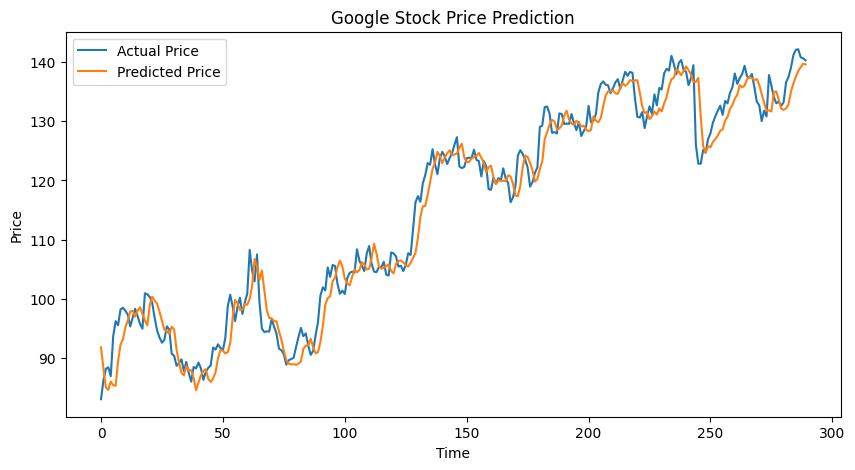

In [4]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Step 1: Download Google stock data (last 5 years)
data = yf.download('GOOG', start='2018-01-01', end='2023-12-31')
close_prices = data['Close'].values.reshape(-1, 1)

# Step 2: Normalize the data
scaler = MinMaxScaler()
scaled_prices = scaler.fit_transform(close_prices)

# Step 3: Create sequences (X = past 60 days, y = next day)
def create_sequences(data, seq_length):
    X = []
    y = []
    for i in range(seq_length, len(data)):
        X.append(data[i - seq_length:i])
        y.append(data[i])
    return np.array(X), np.array(y)

seq_length = 60
X, y = create_sequences(scaled_prices, seq_length)

# Step 4: Split data into train/test
split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

# Step 5: Build a simple RNN model
model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(seq_length, 1)),
    Dense(1)
])

# Step 6: Compile and train
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# Step 7: Make predictions
predicted = model.predict(X_test)
predicted_prices = scaler.inverse_transform(predicted)
actual_prices = scaler.inverse_transform(y_test)

# Step 8: Plot results
plt.figure(figsize=(10, 5))
plt.plot(actual_prices, label='Actual Price')
plt.plot(predicted_prices, label='Predicted Price')
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()
